# Estimate Demand System — Tanzania (Hicks)

## EEP 153 — Project 3

**Deliverable:** Counterfactual Experiments (C)

**Data Source:** [Tanzania - Hicks Google Sheet](https://docs.google.com/spreadsheets/d/1LRe2bjhimuwrTXU8MpmQFH02MJegNRpmwNkY9T3HGqA/edit)

**Survey Waves:** 2019-20 and 2020-21

---

In [1]:
#Importing
import pandas as pd
import numpy as np
from datascience import *
import matplotlib.pyplot as plt
import warnings 
import seaborn as sns
warnings.filterwarnings('ignore')
%matplotlib inline

## Functions

- Function that calculate the total nutrient for each household
- Function that calculate the avergae nutrient for each person in the household
- Function that calculate how many people meeting the RDA requirement

In [2]:
#Reading files
FCT = pd.read_csv('Data/Tanzania - Hicks - FCT.csv')
Household_characteristics = pd.read_csv('Data/Tanzania - Household Characteristics.csv')
Nutrient_requirement = pd.read_csv('Data/Tanzania - Hicks - RDA.csv')

#Reading files for 2019 - 2020
Food_Expenditure_1920_perday = pd.read_csv('Data/Tanzania - Food Expenditures (2019-20).csv')
Food_Expenditure_1920_perday["Expenditure"] = Food_Expenditure_1920_perday["Expenditure"] / 7
Food_Prices_1920 = pd.read_csv('Data/Tanzania - Food Prices (2019-20).csv').dropna(how='any')
Household_characteristics_1920 = Household_characteristics[Household_characteristics['t'] == "2019-20"]

#Reading files for 2020 - 2021
Food_Expenditure_2021_perday = pd.read_csv('Data/Tanzania - Food Expenditures (2020-21).csv')
Food_Expenditure_2021_perday["Expenditure"] = Food_Expenditure_2021_perday["Expenditure"] / 7
Food_Prices_2021 = pd.read_csv('Data/Tanzania - Food Prices (2020-21).csv').dropna(how='any')
Household_characteristics_2021 = Household_characteristics[Household_characteristics['t'] == "2020-21"]

#Mutiplying the expenditure
def change_price(df_expenditure, multiple):
    df_expenditure = df_expenditure.copy()
    df_expenditure["Expenditure"] = df_expenditure["Expenditure"] * multiple
    return df_expenditure



#Total nutrient for each household
def ttl_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price):
    
    #Merging datasets
    merged_df = pd.merge(Household_Characteristic, Expenditure.drop(columns=['t', 'm']), on='i', how='inner')
    merged_df = pd.merge(merged_df, Food_Price, on=["j","m"],how = "left")
    merged_df["Quantity of Food"] = merged_df["Expenditure"] / merged_df["Price"]
    merged_df = merged_df.drop_duplicates(subset=['i', 'j'], keep='first')
    merged_df = merged_df[["i", "m","log HSize", "j","u","Quantity of Food"]]
    merged_df = pd.merge(merged_df, FCT, on='j', how='left')
    
    df_total_nutrients_per_household = merged_df[[
        "i",
        "Quantity of Food",
        "Energy",
        "Protein",
        "Vitamin A",
        "Vitamin D",
        "Vitamin E",
        "Vitamin C",
        "Vitamin B-6",
        "Vitamin B-12",
        "Calcium",
        "Magnesium",
        "Iron",
        "Zinc",
        "Fiber"
    ]]
    
    nutrient_cols = [
        "Energy", "Protein", "Vitamin A", "Vitamin D", "Vitamin E",
        "Vitamin C", "Vitamin B-6", "Vitamin B-12",
        "Calcium", "Magnesium", "Iron", "Zinc", "Fiber"
    ]
    
    #Multiplying nutrients by quantity
    df_total_nutrients_per_household [nutrient_cols] = df_total_nutrients_per_household [nutrient_cols].multiply(df_total_nutrients_per_household ["Quantity of Food"], axis=0)
    
    #Grouping individuals
    df_total_nutrients_per_household = df_total_nutrients_per_household.groupby("i")[nutrient_cols].sum().reset_index()[["i"]+nutrient_cols]
    
    return df_total_nutrients_per_household




#Average nutrient for each person in the household
def avg_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price):
    ttl = ttl_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price)
    ttl_w_household = pd.merge(ttl, Household_Characteristic[["i","log HSize"]], on=["i"], how="left")

    #Create HSize from log HSize
    ttl_w_household["HSize"] = np.exp(
        ttl_w_household["log HSize"]
    )

    #Drop the old column
    ttl_w_household = ttl_w_household.drop(
        columns=["log HSize"]
    )

    nutrient_cols = [
    "Energy", "Protein", "Vitamin A", "Vitamin D", "Vitamin E",
    "Vitamin C", "Vitamin B-6", "Vitamin B-12",
    "Calcium", "Magnesium", "Iron", "Zinc", "Fiber"
    ]

    # divide each nutrient by household size
    ttl_w_household.loc[:, nutrient_cols] = (
        ttl_w_household[nutrient_cols]
        .div(ttl_w_household["HSize"], axis=0)
    )

    return ttl_w_household



#Calculate the total people who meet the nutrition requirement
def num_meet_requirement(FCT, Household_Characteristic, Expenditure, Food_Price, Requirement):
    ttl = ttl_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price)
    avg = avg_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price)
    merged_df = pd.merge(avg, Household_Characteristic, on=["i"], how="left")

    nutrient_cols = [
        "Energy", "Protein", "Vitamin A", "Vitamin D", "Vitamin E",
        "Vitamin C", "Vitamin B-6", "Vitamin B-12",
        "Calcium", "Magnesium", "Iron", "Zinc", "Fiber"
    ]

    demo_cols = [
    "Females 09-13", "Males 14-18", "Females 14-18",
    "Males 19-30", "Females 19-30",
    "Males 31-50", "Females 31-50",
    "Males 51-99", "Females 51-99"
    ]

    def expand_household(row):
        people = []
        for col in demo_cols:
            count = int(row[col])
            people.extend([col] * count)
        return people

    # Add new column to dataframe
    merged_df["household_list"] = merged_df.apply(expand_household, axis=1)

    meet_requirement = []
    
    for i in range(len(merged_df)):
        count = 0
        meet = True
        household_lst = merged_df.iloc[i][-1]
        for j in household_lst:
            for k in range(len(Nutrient_requirement[j])):
                if Nutrient_requirement[j][k] < merged_df.iloc[i][1+k]:
                    continue
                else:
                    meet = False
                    break
            if meet:
                count += 1
        meet_requirement.append(count)

    merged_df["meet_requirement"] = meet_requirement

    #Create HSize from log HSize
    merged_df["HSize"] = np.exp(
        merged_df["log HSize"]
    )

    #Drop the old column
    merged_df = merged_df.drop(
        columns=["log HSize"]
    )
        
    return merged_df



original_1920 = num_meet_requirement(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920, Nutrient_requirement)[['i', 'meet_requirement', "HSize"]]
original_1920

,i,meet_requirement,HSize
0,0001-001-001,0,2.0
1,0001-001-003,0,1.0
2,0001-001-004,0,1.0
3,0001-004-001,0,3.0
4,0001-004-002,0,1.0
...,...,...,...
1105,0856-001-001,0,11.0
1106,0856-001-003,0,7.0
1107,0857-001-001,0,8.0
1108,0858-001-001,0,3.0


In [3]:
avg_nutrient_household(FCT, Household_characteristics_2021, Food_Expenditure_2021_perday, Food_Prices_2021)

,i,Energy,Protein,Vitamin A,Vitamin D,Vitamin E,Vitamin C,Vitamin B-6,Vitamin B-12,Calcium,Magnesium,Iron,Zinc,Fiber,HSize
0,1009-001-01,2149.182616,58.816603,1584.617996,0.991334,2.642097,24.303674,1.181632,3.112034,608.232995,295.222368,15.685791,7.710767,17.562390,4.0
1,1025-001-02,5377.735366,121.900322,2095.911044,0.933170,9.826315,69.727758,3.558539,0.772881,567.390234,1046.158884,39.695748,20.674890,74.293718,1.0
2,1039-001-01,1910.239137,45.326214,296.335762,1.661375,1.739179,6.197029,0.856474,0.152293,124.602432,344.311390,12.157433,7.548482,20.675409,5.0
3,1078-001-01,1225.602617,27.174248,205.921603,1.160072,7.741562,68.411976,1.360819,0.689541,257.896065,232.068881,6.757324,3.706796,19.188681,7.0
4,1102-001-01,707.039621,11.168658,144.606388,0.000000,1.202028,1.533030,0.313122,0.272160,108.663565,139.661305,3.759080,1.936492,6.944158,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,9760-001-99,1801.620335,33.806673,456.554055,0.000000,2.070365,68.857452,1.623087,0.000000,174.851422,383.292296,15.655299,8.038139,21.835579,4.0
402,9772-001-99,1040.258813,22.909727,83.994550,2.658199,1.842580,18.135625,0.699485,0.243668,51.621553,239.934212,6.250427,3.721416,12.633186,5.0
403,9784-001-99,979.623386,16.941982,553.010332,0.747619,2.419806,61.909372,0.811136,0.068532,152.866248,266.837083,8.367300,3.803680,15.667823,4.0
404,9796-001-99,1274.666082,39.323727,439.734302,7.974598,3.436815,5.020252,1.051045,0.731005,122.430923,413.433317,10.687554,5.610861,18.363575,5.0


In [4]:
ttl_nutrient_household(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920)

,i,Energy,Protein,Vitamin A,Vitamin D,Vitamin E,Vitamin C,Vitamin B-6,Vitamin B-12,Calcium,Magnesium,Iron,Zinc,Fiber
0,0001-001-001,4443.459746,126.241561,3240.826667,0.000000,4.788366,101.124419,3.353906,0.392710,3198.637064,680.531086,42.248447,17.872642,143.617188
1,0001-001-003,3896.941970,105.411879,2880.363211,2.250010,5.591876,90.589455,3.218431,1.971149,2086.412699,744.339394,40.461397,18.705572,102.037015
2,0001-001-004,4677.468048,133.455172,3350.879529,14.425000,11.031091,201.362549,4.202957,4.582546,525.333374,1019.818641,33.497141,21.349679,50.113305
3,0001-004-001,7521.316776,170.790871,6171.022003,3.250014,20.979745,94.602114,4.086384,3.101793,3006.400041,1007.370723,42.712547,21.678869,128.119848
4,0001-004-002,2184.088986,41.301171,835.671518,0.474737,1.394198,11.886413,1.353456,0.000000,1648.805168,236.665677,18.407093,7.405535,76.442074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1105,0856-001-001,5919.725103,86.100448,2630.003286,27.169264,3.709503,68.680207,1.058970,2.490516,1191.389760,368.940710,10.571486,7.337074,133.198964
1106,0856-001-003,6826.623824,159.269359,99.608380,27.169264,5.355353,47.623505,2.863006,2.490516,433.598129,778.435862,16.531044,15.268848,58.340132
1107,0857-001-001,8966.288256,225.746947,632.731083,40.753895,16.393394,129.717740,5.100354,5.109645,1926.051587,1159.166645,34.091356,23.460284,154.542131
1108,0858-001-001,5382.591273,147.988296,4742.936366,9.015625,15.307547,64.413502,4.507525,0.826432,976.611629,1880.353683,60.828077,27.848190,97.424889


## Graph 1 and 2. Graph of Multiple of Expenditure vs Num of Meeting Requirement for 2019-2020 and 2020-2021

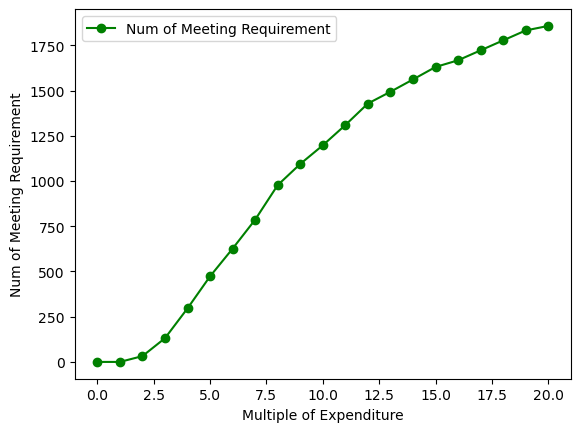

Total Number of People in the Dataset:  5434.0


In [5]:
def graph_meeting_nutrients(FCT, Household_Characteristic, Expenditure, Food_Price, Requirement):
    
    multiples_of_expenditures = list(range(21))
    ttl_meet_requirement = []
    for i in multiples_of_expenditures:
        current = num_meet_requirement(FCT, Household_Characteristic, change_price(Expenditure, i), Food_Price, Requirement)
        ttl_meet_requirement.append(sum(current['meet_requirement']))

    df = pd.DataFrame({
        "Multiple of Expenditure": multiples_of_expenditures,
        "Num of Meeting Requirement": ttl_meet_requirement
        })
    
    df.plot(x="Multiple of Expenditure", y="Num of Meeting Requirement", color="green", marker='o')
    plt.xlabel("Multiple of Expenditure")
    plt.ylabel("Num of Meeting Requirement")
    plt.show()
    print("Total Number of People in the Dataset: " , round(sum(avg_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price)["HSize"]),0))

graph_meeting_nutrients(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920, Nutrient_requirement)

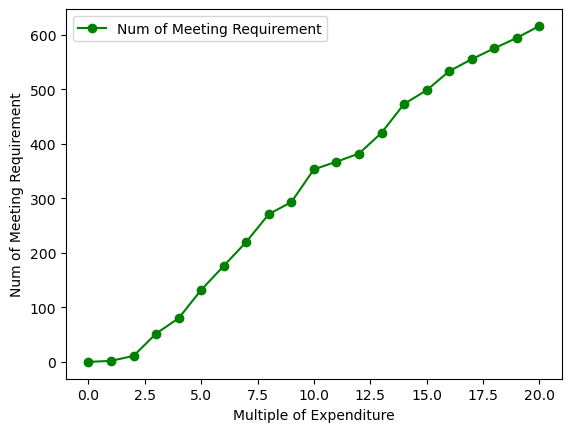

Total Number of People in the Dataset:  2198.0


In [6]:
graph_meeting_nutrients(FCT, Household_characteristics_2021, Food_Expenditure_2021_perday, Food_Prices_2021, Nutrient_requirement)

## Graph 3 and 4. Graph of Mutiple of Expenditure vs Num of Meeting Requirement for 2019-2020 and 2020-2021, grouped by region

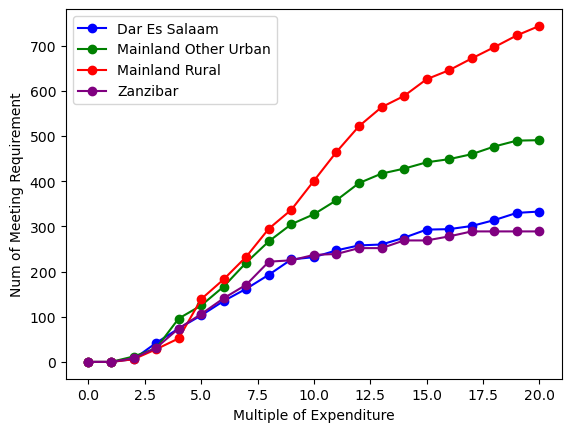

Total Number of People in the each region in the dataset: 
Dar Es Salaam :  630.0
Mainland Other Urban :  1223.0
Mainland Rural :  2953.0
Zanzibar :  628.0


In [7]:
list_of_regions = ['Dar Es Salaam','Mainland Other Urban','Mainland Rural','Zanzibar']

def graph_meeting_nutrients_by_region(FCT, Household_Characteristic, Expenditure, Food_Price, Requirement):

    meet_req_region = {"Multiple of Expenditure":list(range(21))}
    
    for j in list_of_regions:
        HC = Household_Characteristic[Household_Characteristic['m'] == j]
        multiples_of_expenditures = list(range(21))
        ttl_meet_requirement = []
        for i in multiples_of_expenditures:
            current = num_meet_requirement(FCT, HC, change_price(Expenditure, i), Food_Price, Requirement)
            ttl_meet_requirement.append(sum(current['meet_requirement']))
        meet_req_region[j] = ttl_meet_requirement

    df = pd.DataFrame(meet_req_region)
    
    df.plot(x="Multiple of Expenditure", y=list_of_regions, color=['blue', 'green', 'red', 'purple'], marker='o') #Assuming four regions
    plt.xlabel("Multiple of Expenditure")
    plt.ylabel("Num of Meeting Requirement")
    plt.show()
    print("Total Number of People in the each region in the dataset: ")
    for i in list_of_regions:
        print(i,": ", round(sum(avg_nutrient_household(FCT, Household_Characteristic[Household_Characteristic['m'] == i] , Expenditure, Food_Price)["HSize"]),0))

graph_meeting_nutrients_by_region(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920, Nutrient_requirement)

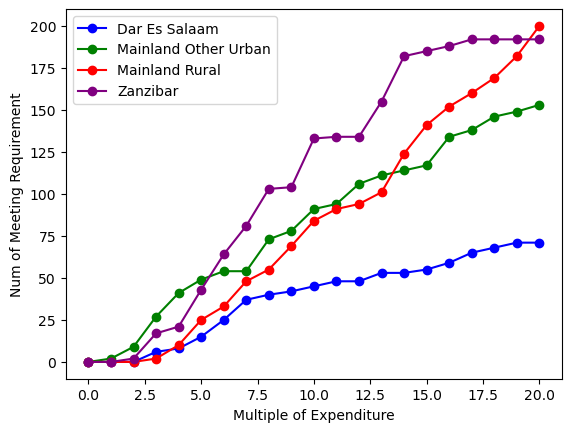

Total Number of People in the each region in the dataset: 
Dar Es Salaam :  235.0
Mainland Other Urban :  495.0
Mainland Rural :  1145.0
Zanzibar :  323.0


In [8]:
graph_meeting_nutrients_by_region(FCT, Household_characteristics_2021, Food_Expenditure_2021_perday, Food_Prices_2021, Nutrient_requirement)

## Graph 5 and 6. Graph of Multiple of Expenditure vs Num of Meeting Requirement for 2019-2020 and 2020-2021, grouped by region, by proportion

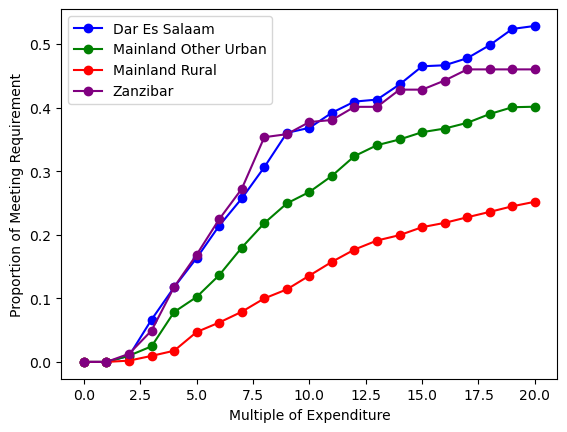

Total Number of People in the each region in the dataset: 
Dar Es Salaam :  630.0
Mainland Other Urban :  1223.0
Mainland Rural :  2953.0
Zanzibar :  628.0


In [9]:
list_of_regions = ['Dar Es Salaam','Mainland Other Urban','Mainland Rural','Zanzibar']

def graph_meeting_nutrients_by_region_p(FCT, Household_Characteristic, Expenditure, Food_Price, Requirement):

    meet_req_region = {"Multiple of Expenditure":list(range(21))}
    
    for j in list_of_regions:
        HC = Household_Characteristic[Household_Characteristic['m'] == j]
        multiples_of_expenditures = list(range(21))
        ttl_meet_requirement = []
        for i in multiples_of_expenditures:
            current = num_meet_requirement(FCT, HC, change_price(Expenditure, i), Food_Price, Requirement)
            ttl_meet_requirement.append(sum(current['meet_requirement']) / round(sum(avg_nutrient_household(FCT, HC , Expenditure, Food_Price)["HSize"]),0))
        meet_req_region[j] = ttl_meet_requirement

    df = pd.DataFrame(meet_req_region)
    
    df.plot(x="Multiple of Expenditure", y=list_of_regions, color=['blue', 'green', 'red', 'purple'], marker='o') #Assuming four regions
    plt.xlabel("Multiple of Expenditure")
    plt.ylabel("Proportion of Meeting Requirement")
    plt.show()
    print("Total Number of People in the each region in the dataset: ")
    for i in list_of_regions:
        print(i,": ", round(sum(avg_nutrient_household(FCT, Household_Characteristic[Household_Characteristic['m'] == i] , Expenditure, Food_Price)["HSize"]),0))

graph_meeting_nutrients_by_region_p(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920, Nutrient_requirement)

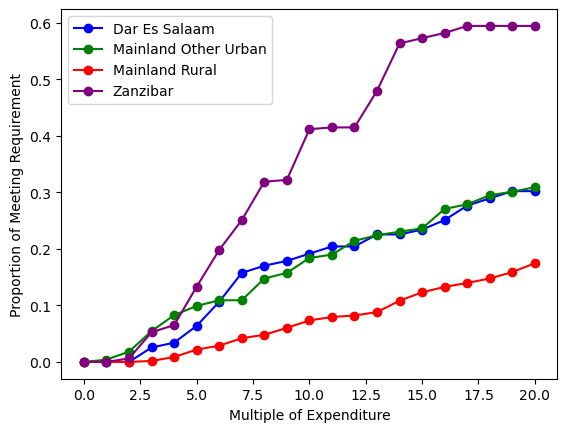

Total Number of People in the each region in the dataset: 
Dar Es Salaam :  235.0
Mainland Other Urban :  495.0
Mainland Rural :  1145.0
Zanzibar :  323.0


In [10]:
graph_meeting_nutrients_by_region_p(FCT, Household_characteristics_2021, Food_Expenditure_2021_perday, Food_Prices_2021, Nutrient_requirement)

## Graph 7 and 8. Graph of Multiple of Expenditure vs Num of Meeting Requirement for 2019-2020 and 2020-2021, grouped by household size, by proportion

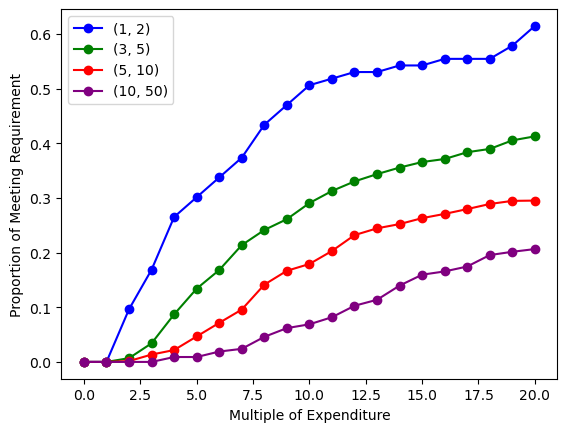

In [11]:
list_of_hsize = [(1,2),(3,5),(5,10),(10,50)]

def graph_meeting_nutrients_by_hsize_p(FCT, Household_Characteristic, Expenditure, Food_Price, Requirement):

    meet_req_region = {"Multiple of Expenditure":list(range(21))}

    H_C = Household_Characteristic.copy()
        
    H_C["HSize"] = np.exp(
        H_C["log HSize"]
        )

    
    for j in list_of_hsize:

        HC = H_C[(H_C['HSize'] >= j[0]) & (H_C['HSize'] <= j[1])]
        multiples_of_expenditures = list(range(21))
        ttl_meet_requirement = []
        
        for i in multiples_of_expenditures:
            current = num_meet_requirement(FCT, HC, change_price(Expenditure, i), Food_Price, Requirement)
            ttl_meet_requirement.append(sum(current['meet_requirement']) / round(sum(avg_nutrient_household(FCT, HC , Expenditure, Food_Price)["HSize"]),0))
        meet_req_region[j] = ttl_meet_requirement

    df = pd.DataFrame(meet_req_region)
    
    df.plot(x="Multiple of Expenditure", y=list_of_hsize, color=['blue', 'green', 'red', 'purple'], marker='o') #Assuming four regions
    plt.xlabel("Multiple of Expenditure")
    plt.ylabel("Proportion of Meeting Requirement")
    plt.show()

graph_meeting_nutrients_by_hsize_p(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920, Nutrient_requirement)

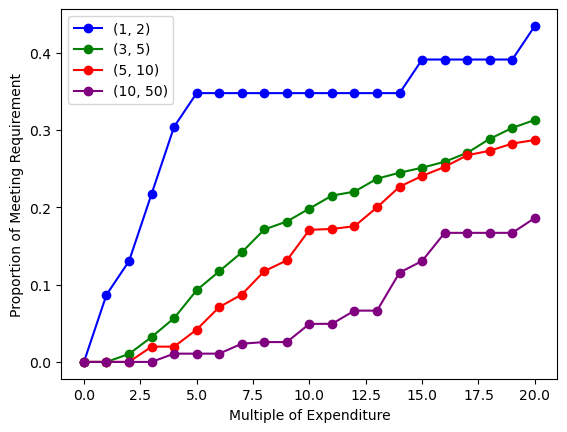

In [12]:
graph_meeting_nutrients_by_hsize_p(FCT, Household_characteristics_2021, Food_Expenditure_2021_perday, Food_Prices_2021, Nutrient_requirement)

## Graph 9 and 10. Graph of average nutrients compare to RDA of age groups in 2019-2020 and 2020-2021

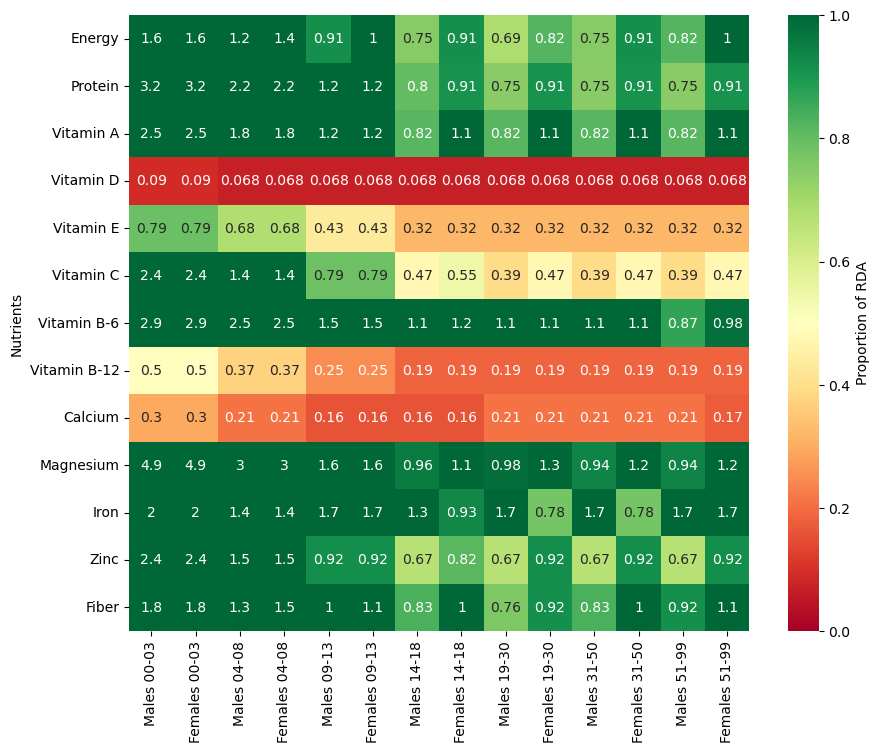

In [16]:
#Input the output create by the function avg_nutrient_household
def heat_map(avg, nutrient_req):
    age_sex_labels = nutrient_req.columns[1:].tolist()

    def weighted_median(values, weights):
        sorted_idx = np.argsort(values)
        values_sorted = values[sorted_idx]
        weights_sorted = weights[sorted_idx]
        
        cumulative_weight = np.cumsum(weights_sorted)
        cutoff = weights_sorted.sum() / 2
        
        return values_sorted[cumulative_weight >= cutoff][0]

    nutrient_cols = ['Energy','Protein','Vitamin A','Vitamin D','Vitamin E',
                         'Vitamin C','Vitamin B-6','Vitamin B-12',
                         'Calcium','Magnesium','Iron','Zinc','Fiber']
    
    avg_divide = avg[nutrient_cols].apply(
        lambda col: weighted_median(col.values, avg['HSize'].values)
    )

    avg_list = avg_divide.to_list()

        
    nutrients = avg.index
    
    heatmap_df = {'Nutrients':nutrient_cols}
    
    for i in age_sex_labels:
        prop = []
        for j in range(len(avg_list)):
            prop.append(avg_list[j] / nutrient_req[i][j])
        heatmap_df[i] = prop
  

    
    heatmap_df = pd.DataFrame(heatmap_df)
    
    heatmap_df.set_index('Nutrients', inplace=True)
    
    # Create the heatmap
    plt.figure(figsize=(10,8))
    sns.heatmap(heatmap_df, annot=True, cmap='RdYlGn', vmin=0,vmax=1,cbar_kws={'label': 'Proportion of RDA'})
    plt.ylabel('Nutrients')
    plt.show()


heat_map(avg_nutrient_household(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920), Nutrient_requirement)

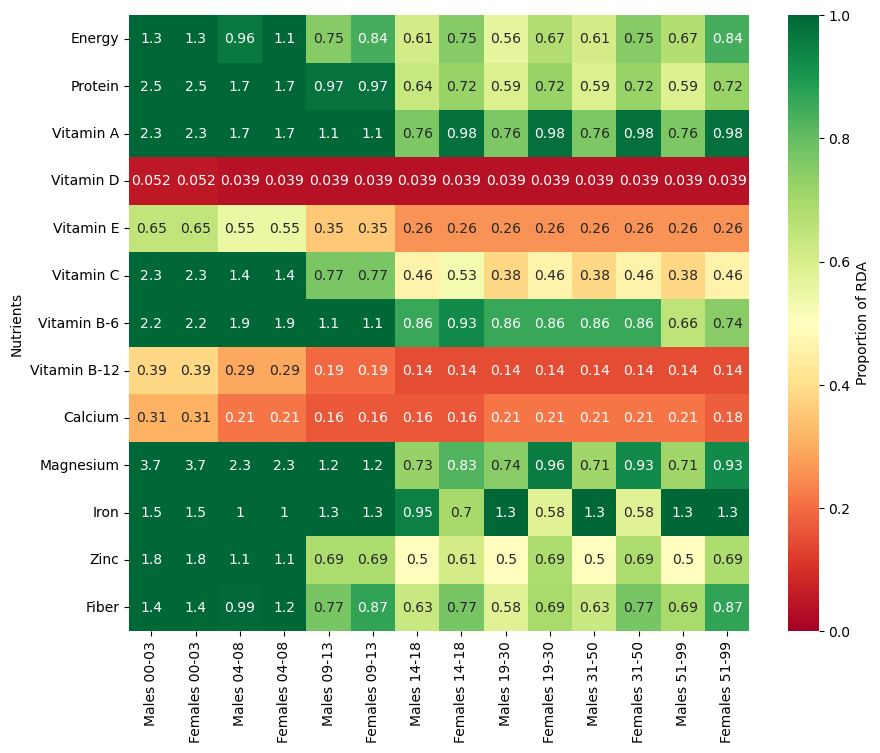

In [17]:
heat_map(avg_nutrient_household(FCT, Household_characteristics_2021, Food_Expenditure_2021_perday, Food_Prices_2021), Nutrient_requirement)